# seaborn

We will start our very broad discussion of data visualization with [seaborn](https://seaborn.pydata.org). `seaborn` is based on `matplotlib`, but is "higher-level" (i.e. easier to use) and makes what many consider nicer looking graphs (i.e. many = me). 

So, why do we still look at `matplotlib`? I think it is good to see `matplotlib`, since it is the most popular way to create figures in Python. But, you should take a look at `seaborn` as well.

[Some people](https://www.emilyriederer.com/post/py-rgo/), especially those coming to Python from other languages, are suggesting that you just start with `seaborn` instead.

`seaborn` comes with Anaconda and Github Codespaces, so there's nothing to install. Just add `import seaborn as sns` to your set-up and you're ready to go. In my set-up, I'll set a theme, so that the same theme is used across all of my graphs. I'll create my returns directly in the **stocks** DataFrame.

DataCamp has a [seaborn tutorial](https://www.datacamp.com/community/tutorials/seaborn-python-tutorial) as well.

There's an [example gallery](https://seaborn.pydata.org/examples/index.html) as well.

You can find other examples [here](https://pythonforfinance.net/2018/07/22/seaborn-module-and-python-distribution-plots/).

Finally, I'm going to use the `df.var_name` convention for pulling out variables from a DataFrame. I find it easier than `df['var_name']`. I'll go back and forth in the notes, to get you use to the different styles.


In [1]:
# Set-up
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="white")

# Include this to have plots show up in your Jupyter notebook.
%matplotlib inline 

# Read in some eod prices
stocks = pd.read_csv('https://raw.githubusercontent.com/aaiken1/fin-data-analysis-python/main/data/tr_eikon_eod_data.csv',
                  index_col=0, parse_dates=True)  

stocks.dropna(inplace=True)  

from janitor import clean_names

stocks = clean_names(stocks)

stocks['aapl_ret'] = np.log(stocks.aapl_o / stocks.aapl_o.shift(1))  
stocks['msft_ret'] = np.log(stocks.msft_o / stocks.msft_o.shift(1))  

stocks.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2138 entries, 2010-01-04 to 2018-06-29
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   aapl_o    2138 non-null   float64
 1   msft_o    2138 non-null   float64
 2   intc_o    2138 non-null   float64
 3   amzn_o    2138 non-null   float64
 4   gs_n      2138 non-null   float64
 5   spy       2138 non-null   float64
 6   _spx      2138 non-null   float64
 7   _vix      2138 non-null   float64
 8   eur=      2138 non-null   float64
 9   xau=      2138 non-null   float64
 10  gdx       2138 non-null   float64
 11  gld       2138 non-null   float64
 12  aapl_ret  2137 non-null   float64
 13  msft_ret  2137 non-null   float64
dtypes: float64(14)
memory usage: 250.5 KB


If you don't have `janitor` installed, you'll need to run in a code cell above your set-up code. You should only have to install a package once per code space.

```
pip install pyjanitor
```

You can read more about `janitor` [here](https://pyjanitor-devs.github.io/pyjanitor/#installation).

Let's start with a line plot. We'll plot just AAPL to start.

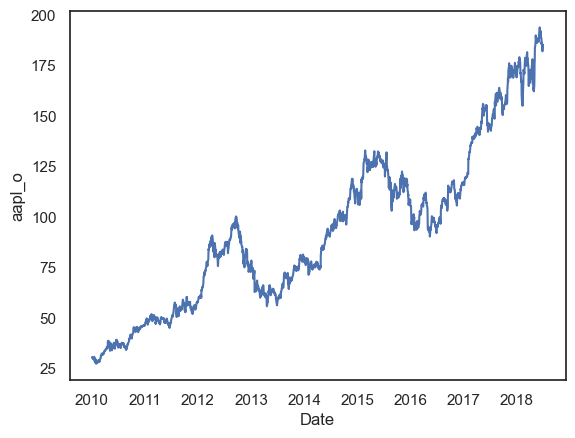

In [2]:
sns.lineplot(x=stocks.index, y=stocks.aapl_o)
plt.show();

We can also make a distribution, or histogram, as well. I'll add what's called the **kernel density estimate** (kde), which gives the distribution. We'll do more data work like this when thinking about **risk**.

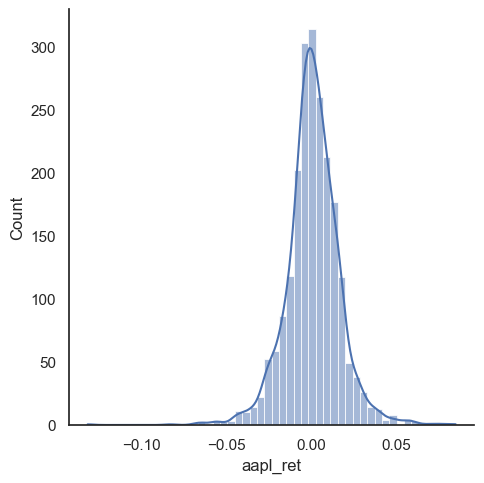

In [3]:
sns.displot(stocks.aapl_ret, kde=True, bins=50)
plt.show();

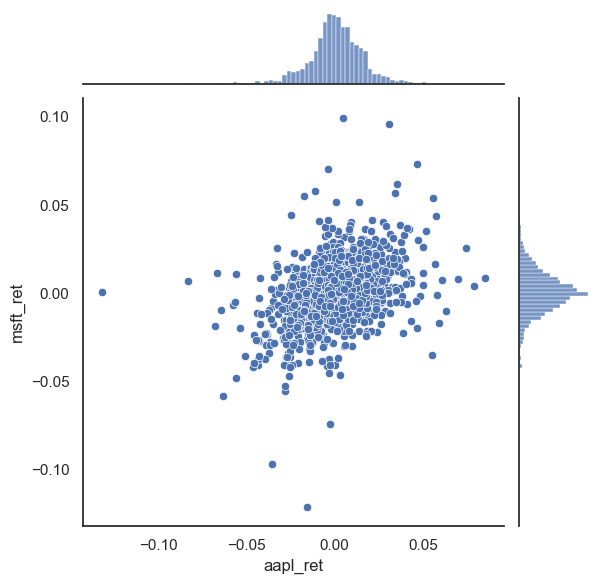

In [4]:
sns.jointplot(x=stocks.aapl_ret, y=stocks.msft_ret)
plt.show();

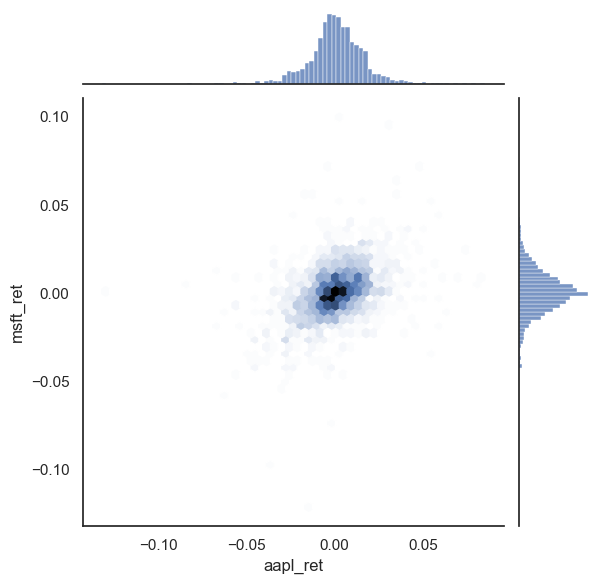

In [5]:
sns.jointplot(x=stocks.aapl_ret, y=stocks.msft_ret, kind='hex')
plt.show();

## Correlation heatmaps

One of the most important visualizations in finance is the **correlation heatmap**. When building a portfolio, you want to know which assets move together and which provide diversification. A heatmap shows all pairwise correlations at once.

Let's create returns for several assets and visualize their correlations.

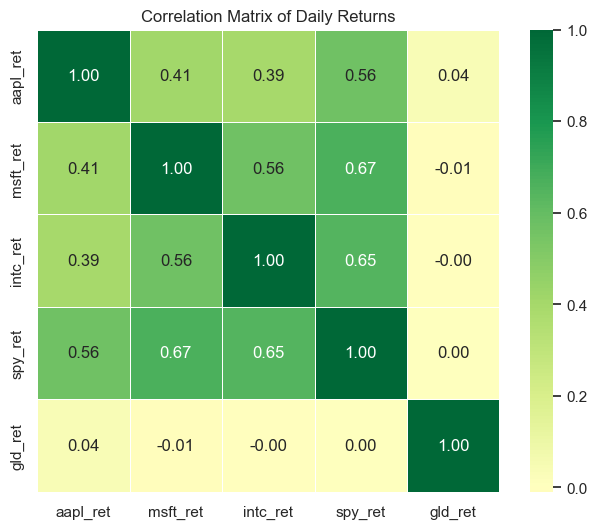

In [6]:
# Create returns for multiple assets
stocks['spy_ret'] = np.log(stocks.spy / stocks.spy.shift(1))
stocks['gld_ret'] = np.log(stocks.gld / stocks.gld.shift(1))
stocks['intc_ret'] = np.log(stocks.intc_o / stocks.intc_o.shift(1))

# Select just the return columns
returns = stocks[['aapl_ret', 'msft_ret', 'intc_ret', 'spy_ret', 'gld_ret']].dropna()

# Calculate the correlation matrix
corr_matrix = returns.corr()

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Daily Returns')
plt.show();

Notice a few things:
- **Green = positive correlation**: Assets that move together (tech stocks like AAPL, MSFT, and INTC)
- **Red = negative correlation**: Assets that move in opposite directions (good for diversification)
- **The diagonal is always 1.0**: Every asset is perfectly correlated with itself
- **Gold (GLD) has low correlation with stocks**: This is why gold is often used as a portfolio diversifier

The `annot=True` argument adds the numbers to each cell. The `cmap='RdYlGn'` sets the color scheme (Red-Yellow-Green), and `center=0` makes sure that zero correlation appears as yellow.

## Box plots

**Box plots** (also called box-and-whisker plots) are excellent for comparing distributions across categories. They show the median, quartiles, and outliers in a compact format. In finance, we often use them to compare return distributions across different assets, sectors, or time periods.

In [7]:
# Reshape data from wide to long format for boxplot
# We need one column for the asset name and one for the return value
returns_long = returns.melt(var_name='Asset', value_name='Return')
returns_long.head()

,Asset,Return
0,aapl_ret,0.001727
1,aapl_ret,-0.016034
2,aapl_ret,-0.001850
3,aapl_ret,0.006626
4,aapl_ret,-0.008861


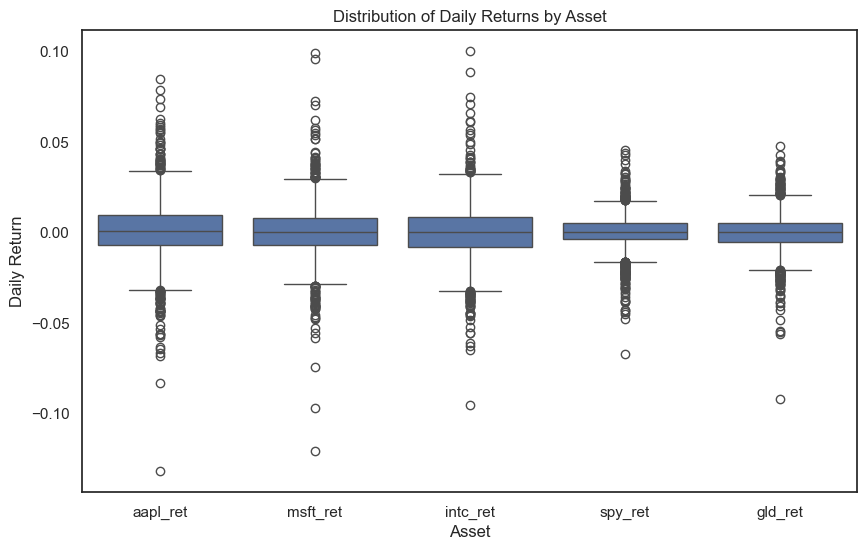

In [8]:
# Create the box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Asset', y='Return', data=returns_long)
plt.title('Distribution of Daily Returns by Asset')
plt.ylabel('Daily Return')
plt.show();

How to read a box plot:
- **The box** spans from the 25th percentile (Q1) to the 75th percentile (Q3)
- **The line inside the box** is the median (50th percentile)
- **The whiskers** extend to 1.5 times the interquartile range (IQR)
- **The dots** are outliers — extreme values beyond the whiskers

Notice how AAPL has more outliers (extreme return days) than SPY. This makes sense — individual stocks are more volatile than diversified index funds.

## Violin plots

A **violin plot** is like a box plot, but it also shows the full shape of the distribution. The width of the "violin" at each point represents how many observations have that value. This gives you more information than a box plot, but can be harder to read at first.

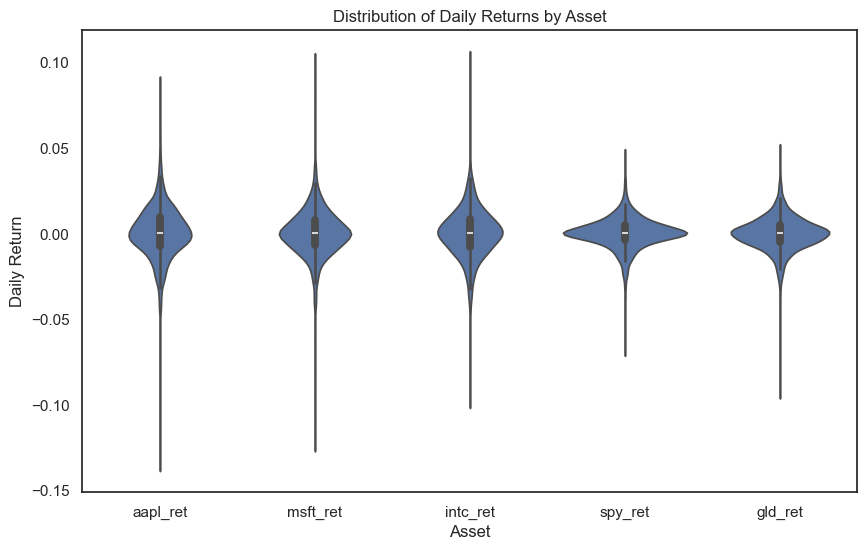

In [9]:
# Create the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Asset', y='Return', data=returns_long)
plt.title('Distribution of Daily Returns by Asset')
plt.ylabel('Daily Return')
plt.show();

The violin shapes show that all these return distributions are roughly symmetric around zero — which is what we'd expect for daily returns. The width in the middle shows that most returns are small (close to zero), with the tails showing less frequent large moves.

## Pair plots

When you want to see the relationships between **all pairs** of variables at once, use a **pair plot**. This creates a grid where:
- The diagonal shows each variable's distribution
- The off-diagonal cells show scatter plots of each pair

This is a quick way to explore relationships in your data.

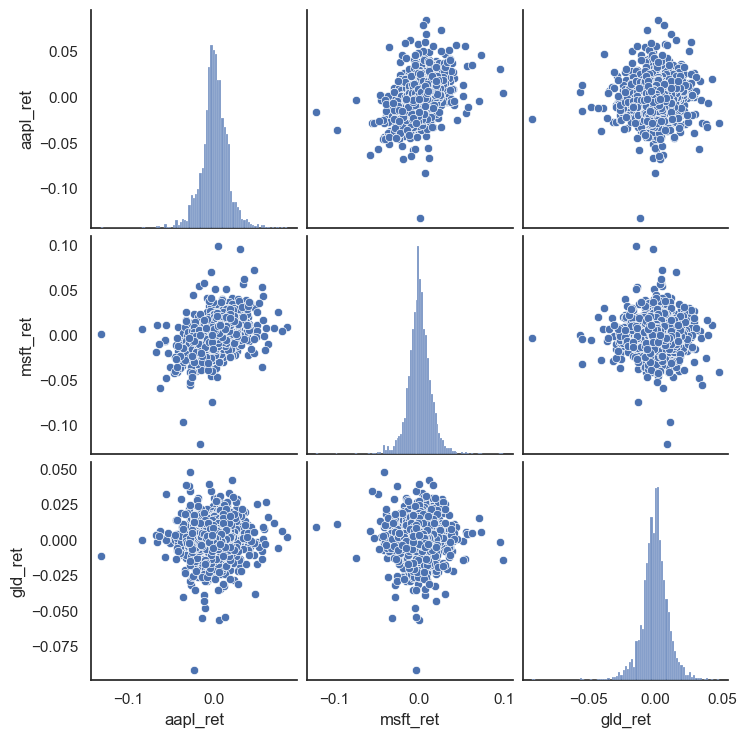

In [10]:
# Pair plot - note this can take a moment with many variables
# We'll use just three assets to keep it readable
returns_subset = returns[['aapl_ret', 'msft_ret', 'gld_ret']].dropna()
sns.pairplot(returns_subset)
plt.show();

Look at the scatter plots: AAPL and MSFT show a clear positive relationship (the cloud tilts upward), while GLD has a much weaker relationship with both stocks. This confirms what we saw in the correlation heatmap — gold provides diversification.

```{tip}
Pair plots get unwieldy with more than 5-6 variables. For larger sets, stick with correlation heatmaps or focus on specific pairs of interest.
```